In [95]:
import pickle
import pandas as pd

tcn_bigru = pickle.load(open("results_tcn_bigru.pkl", "rb"))
tcn       = pickle.load(open("results_tcn.pkl", "rb"))
bigru     = pickle.load(open("results_bigru.pkl", "rb"))

# Langsung pakai
metrics_data = {
    "Model": ["TCN-BiGRU", "TCN", "BiGRU"],
    "RMSE":  [tcn_bigru["rmse"],  tcn["rmse"],  bigru["rmse"]],
    "MAE":   [tcn_bigru["mae"],   tcn["mae"],   bigru["mae"]],
    "MAPE":  [tcn_bigru["mape"],  tcn["mape"],  bigru["mape"]],
    "R²":    [tcn_bigru["r2"],    tcn["r2"],    bigru["r2"]],
}

forecast_h1 = {
    "Model":        ["TCN-BiGRU", "TCN", "BiGRU"],
    "Forecast H+1": [tcn_bigru["forecast_h1"], tcn["forecast_h1"], bigru["forecast_h1"]],
}

forecast_dates        = pd.to_datetime(tcn_bigru["forecast_30_dates"])  # tanggal sama semua
forecast_30_tcn_bigru = tcn_bigru["forecast_30_prices"]
forecast_30_tcn       = tcn["forecast_30_prices"]
forecast_30_bigru     = bigru["forecast_30_prices"]

best_splits = {
    "TCN-BiGRU":  tcn_bigru["best_split"],
    "TCN":   tcn["best_split"],
    "BiGRU": bigru["best_split"],
}

last_actual_price = tcn_bigru["last_actual_price"]
last_actual_date  = tcn_bigru["last_actual_date"]

TABEL RANGKUMAN AKHIR — SEMUA MODEL

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_summary_final = pd.DataFrame([
    {
        "Model":        "TCN",
        "Best Split":   str(tcn["best_split"]),
        "RMSE":         round(tcn["rmse"], 4),
        "MAE":          round(tcn["mae"], 4),
        "MAPE (%)":     round(tcn["mape"], 4),
        "R²":           round(tcn["r2"], 4),
        "Forecast H+1": round(tcn["forecast_h1"], 3),
        "Total Training Time (detik)": round(tcn["total_time"], 2),
    },
    {
        "Model":        "BiGRU",
        "Best Split":   str(bigru["best_split"]),
        "RMSE":         round(bigru["rmse"], 4),
        "MAE":          round(bigru["mae"], 4),
        "MAPE (%)":     round(bigru["mape"], 4),
        "R²":           round(bigru["r2"], 4),
        "Forecast H+1": round(bigru["forecast_h1"], 3),
        "Total Training Time (detik)": round(bigru["total_time"], 2),
    },
    {
        "Model":        "TCN-BiGRU",
        "Best Split":   str(tcn_bigru["best_split"]),
        "RMSE":         round(tcn_bigru["rmse"], 4),
        "MAE":          round(tcn_bigru["mae"], 4),
        "MAPE (%)":     round(tcn_bigru["mape"], 4),
        "R²":           round(tcn_bigru["r2"], 4),
        "Forecast H+1": round(tcn_bigru["forecast_h1"], 3),
        "Total Training Time (detik)": round(tcn_bigru["total_time"], 2),
    },
])

print("=" * 70)
print("TABEL RANGKUMAN AKHIR — SEMUA MODEL")
print("=" * 70)
display(df_summary_final)

TABEL RANGKUMAN AKHIR — SEMUA MODEL


,Model,Best Split,RMSE,MAE,MAPE (%),R²,Forecast H+1,Total Training Time (detik)
0,TCN,"(0.6, 0.2, 0.2)",0.1078,0.0758,1.0553,0.9782,7.170,542.85
1,BiGRU,"(0.6, 0.2, 0.2)",0.1073,0.0763,1.0632,0.9784,7.184,707.10
2,TCN-BiGRU,"(0.6, 0.2, 0.2)",0.1096,0.0773,1.0766,0.9775,7.210,1876.93


BAR CHART METRIK

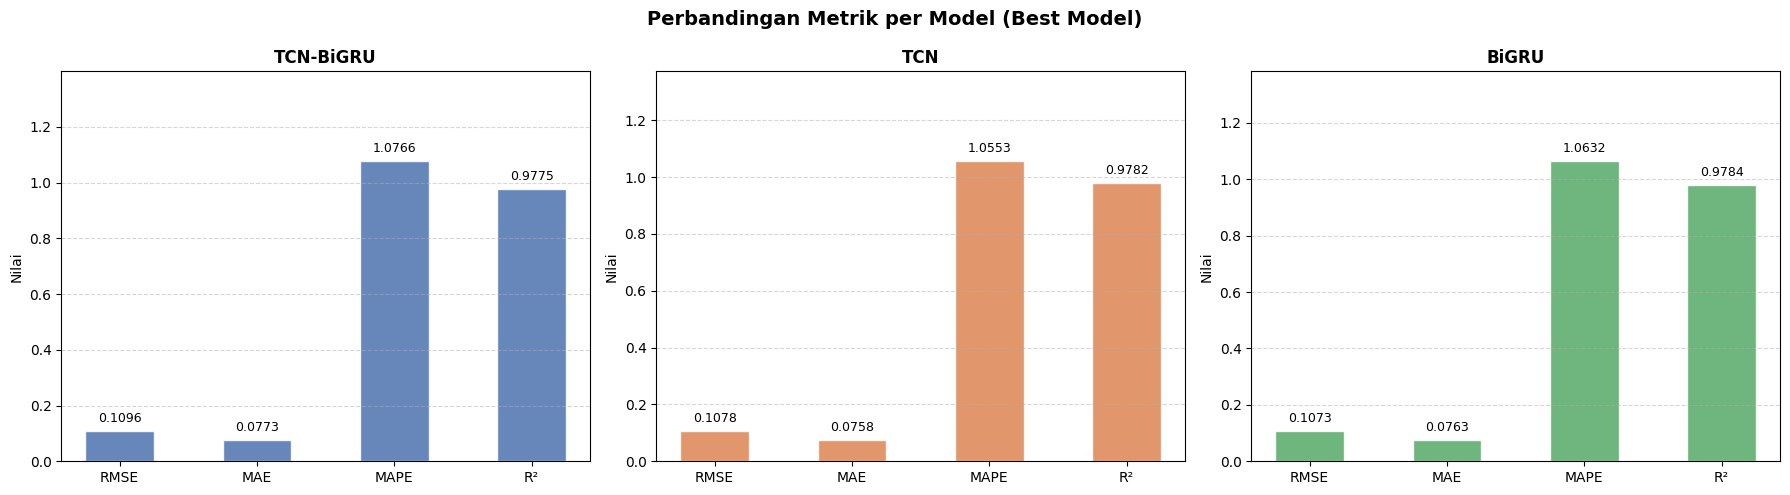

In [97]:
models  = metrics_data["Model"]
colors  = ["#4C72B0", "#DD8452", "#55A868"]
metrics = ["RMSE", "MAE", "MAPE", "R²"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Perbandingan Metrik per Model (Best Model)", fontsize=14, fontweight='bold')

for ax_idx, (ax, model_name, color) in enumerate(zip(axes, models, colors)):
    values = [
        metrics_data["RMSE"][ax_idx],
        metrics_data["MAE"][ax_idx],
        metrics_data["MAPE"][ax_idx],
        metrics_data["R²"][ax_idx],
    ]
    bars = ax.bar(metrics, values, color=color, alpha=0.85, edgecolor='white', width=0.5)
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_ylabel("Nilai")
    ax.set_ylim(0, max(values) * 1.3 if max(values) > 0 else 1)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(values) * 0.02,
                f"{val:.4f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


FORECAST H+1 MASING-MASING MODEL


,Model,Forecast H+1 (Rp)
0,TCN-BiGRU,7.210
1,TCN,7.170
2,BiGRU,7.184


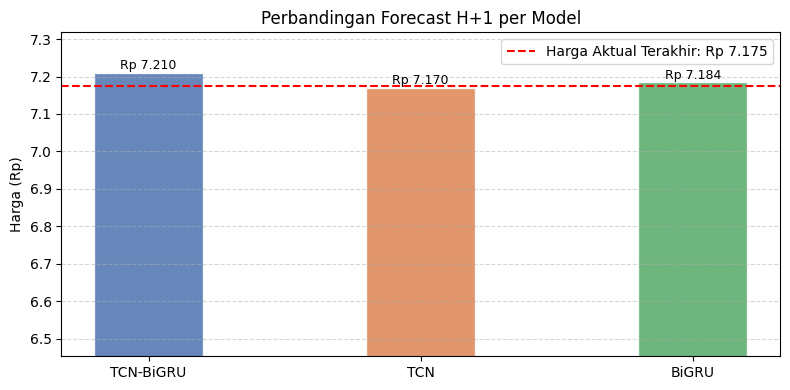

In [98]:
# ===============================
# CELL 4 — TABEL + CHART FORECAST H+1
# ===============================
df_h1 = pd.DataFrame(forecast_h1)
df_h1 = df_h1.rename(columns={"Forecast H+1": "Forecast H+1 (Rp)"})
df_h1["Forecast H+1 (Rp)"] = df_h1["Forecast H+1 (Rp)"].map(lambda x: f"{x:.3f}")
print("\n" + "=" * 40)
print("FORECAST H+1 MASING-MASING MODEL")
print("=" * 40)
display(df_h1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(forecast_h1["Model"], forecast_h1["Forecast H+1"],
              color=colors, alpha=0.85, edgecolor='white', width=0.4)

ax.axhline(y=last_actual_price, color='red', linestyle='--', linewidth=1.5,
           label=f'Harga Aktual Terakhir: Rp {last_actual_price:,.3f}')

for bar, val in zip(bars, forecast_h1["Forecast H+1"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (max(forecast_h1["Forecast H+1"]) - min(forecast_h1["Forecast H+1"])) * 0.05,
            f"Rp {val:,.3f}", ha='center', va='bottom', fontsize=9)

# ← INI KUNCINYA: set ylim mulai dari sedikit di bawah nilai terendah
all_values = forecast_h1["Forecast H+1"] + [last_actual_price]
y_min = min(all_values) * 0.9   # 9% di bawah nilai terkecil
y_max = max(all_values) * 1.015   # 1.5% di atas nilai terbesar
ax.set_ylim(y_min, y_max)

ax.set_title("Perbandingan Forecast H+1 per Model")
ax.set_ylabel("Harga (Rp)")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Perbandingan Metrik Antar Model

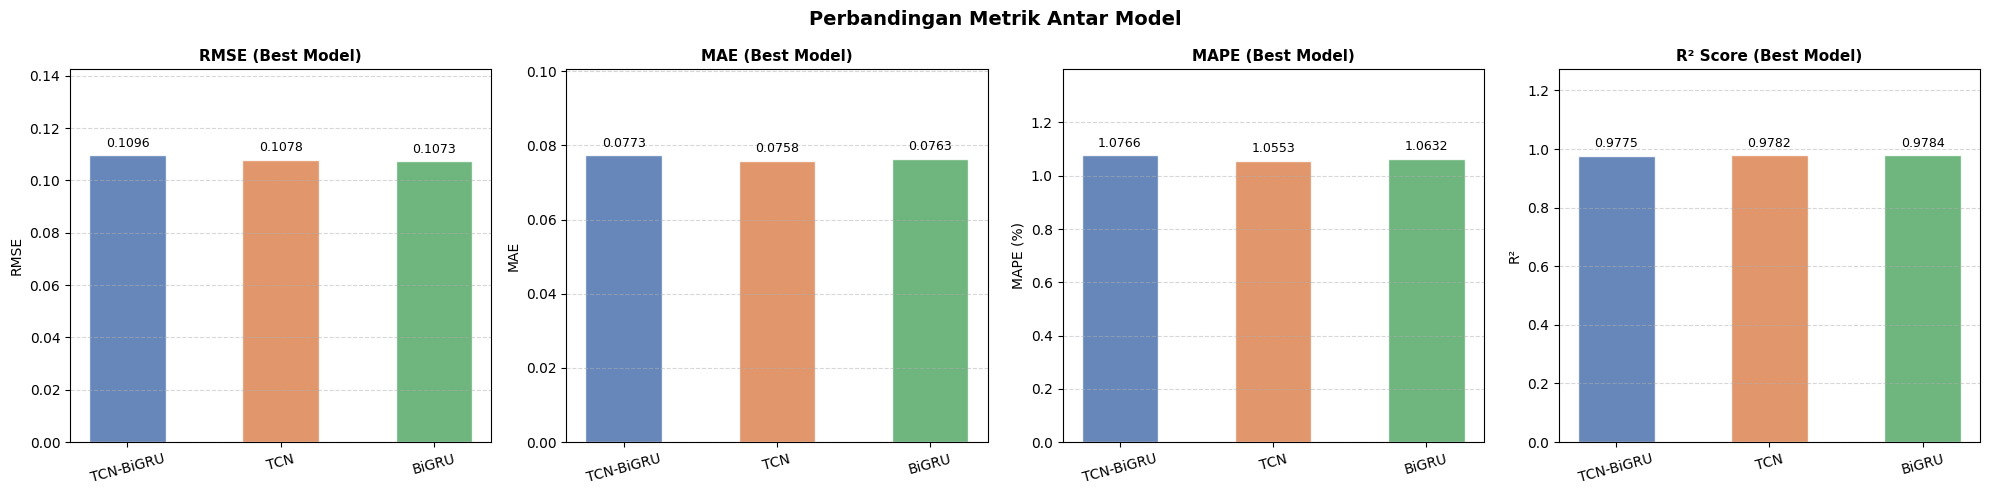

In [99]:
models  = ["TCN-BiGRU", "TCN", "BiGRU"]
colors  = ["#4C72B0", "#DD8452", "#55A868"]
x       = np.arange(len(models))
width   = 0.5

metric_info = [
    ("RMSE",     [tcn_bigru["rmse"],  tcn["rmse"],  bigru["rmse"]],  "RMSE (Best Model)"),
    ("MAE",      [tcn_bigru["mae"],   tcn["mae"],   bigru["mae"]],   "MAE (Best Model)"),
    ("MAPE (%)", [tcn_bigru["mape"],  tcn["mape"],  bigru["mape"]],  "MAPE (Best Model)"),
    ("R²",       [tcn_bigru["r2"],    tcn["r2"],    bigru["r2"]],    "R² Score (Best Model)"),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Perbandingan Metrik Antar Model", fontsize=14, fontweight='bold')

for ax, (ylabel, values, title) in zip(axes, metric_info):
    bars = ax.bar(models, values, color=colors, alpha=0.85, edgecolor='white', width=width)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(values) * 1.3)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(values) * 0.02,
                f"{val:.4f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

ANALISIS TIME PROCESS

TABEL ANALISIS TIME PROCESS


,Model,Total Training Time (menit),Rata-rata per Kombinasi (dtk),Tercepat (dtk),Terlama (dtk),Jumlah Kombinasi
0,TCN-BiGRU,31.28,38.43,14.34,104.45,48
1,TCN,9.05,22.10,8.46,52.30,24
2,BiGRU,11.79,58.13,29.29,107.84,12


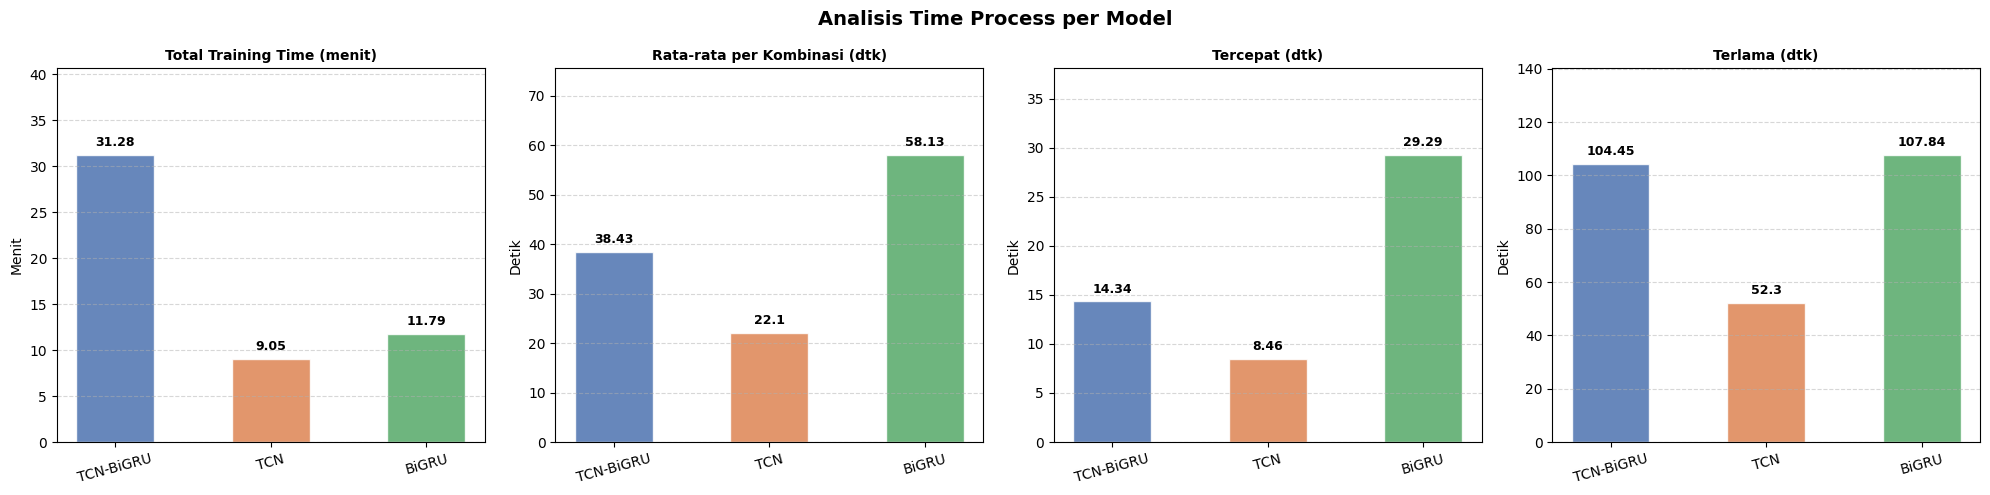

In [ ]:
def time_stats(pkl, model_name):
    times = pkl["tuning_times"]
    return {
        "Model":                      model_name,
        "Total Training Time (menit)": round(pkl["total_time"] / 60, 2),
        "Rata-rata per Kombinasi (dtk)": round(np.mean(times), 2),
        "Tercepat (dtk)":              round(np.min(times), 2),
        "Terlama (dtk)":               round(np.max(times), 2),
        "Jumlah Kombinasi":            len(times),
    }

df_time = pd.DataFrame([
    time_stats(tcn_bigru, "TCN-BiGRU"),
    time_stats(tcn,       "TCN"),
    time_stats(bigru,     "BiGRU"),
])

print("=" * 60)
print("TABEL ANALISIS TIME PROCESS")
print("=" * 60)
display(df_time)

models  = df_time["Model"].tolist()
colors  = ["#4C72B0", "#DD8452", "#55A868"]
x       = np.arange(len(models))
width   = 0.25

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Analisis Time Process per Model", fontsize=14, fontweight='bold')

time_metrics = [
    ("Total Training Time (menit)", df_time["Total Training Time (menit)"].tolist(), "Menit"),
    ("Rata-rata per Kombinasi (dtk)", df_time["Rata-rata per Kombinasi (dtk)"].tolist(), "Detik"),
    ("Tercepat (dtk)", df_time["Tercepat (dtk)"].tolist(), "Detik"),
    ("Terlama (dtk)", df_time["Terlama (dtk)"].tolist(), "Detik"),
]

for ax, (title, values, ylabel) in zip(axes, time_metrics):
    bars = ax.bar(models, values, color=colors, alpha=0.85, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(values) * 1.3)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(values) * 0.02,
                f"{val}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

FORECAST 30 HARI PERALGORITMA

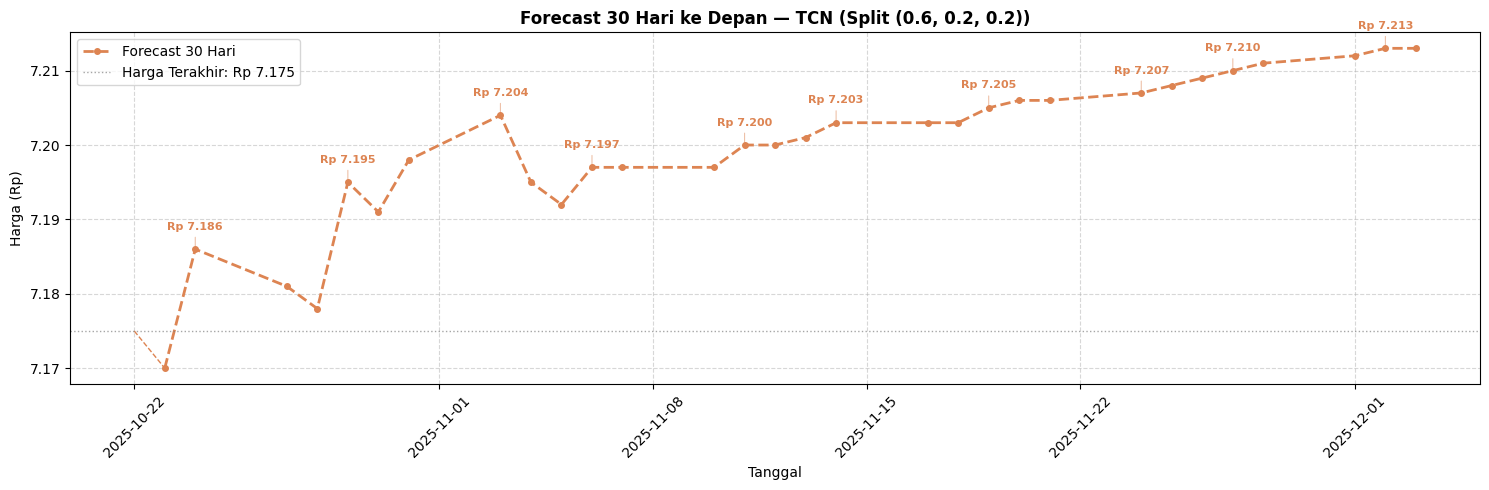

TCN
  Forecast Hari ke-1  : Rp 7.170
  Forecast Hari ke-30 : Rp 7.213



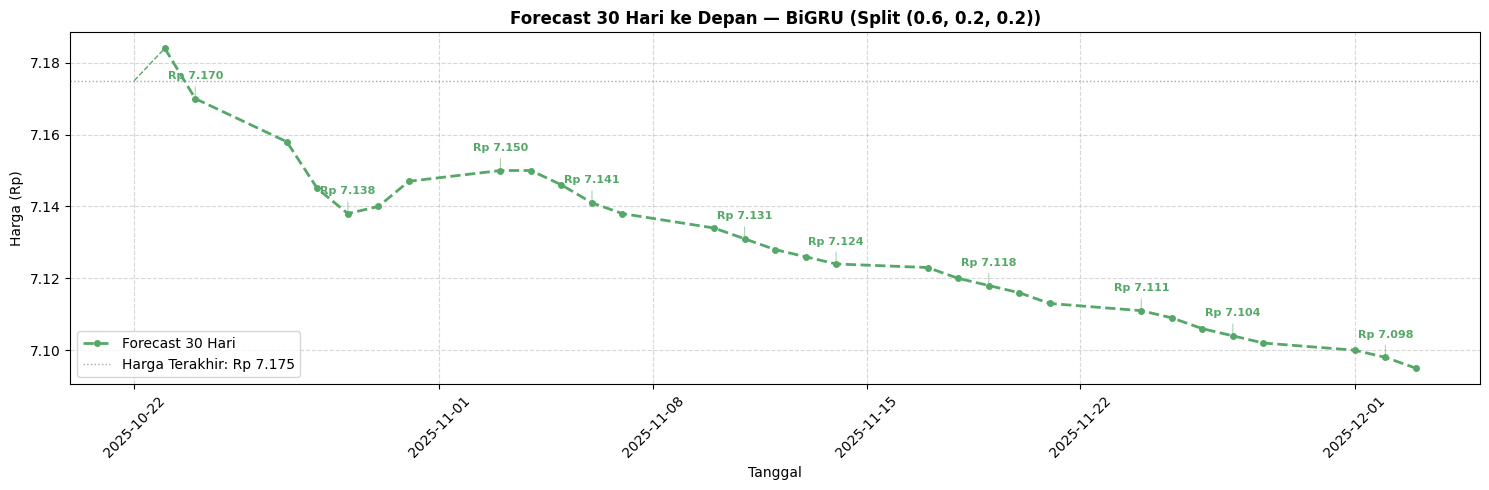

BiGRU
  Forecast Hari ke-1  : Rp 7.184
  Forecast Hari ke-30 : Rp 7.095



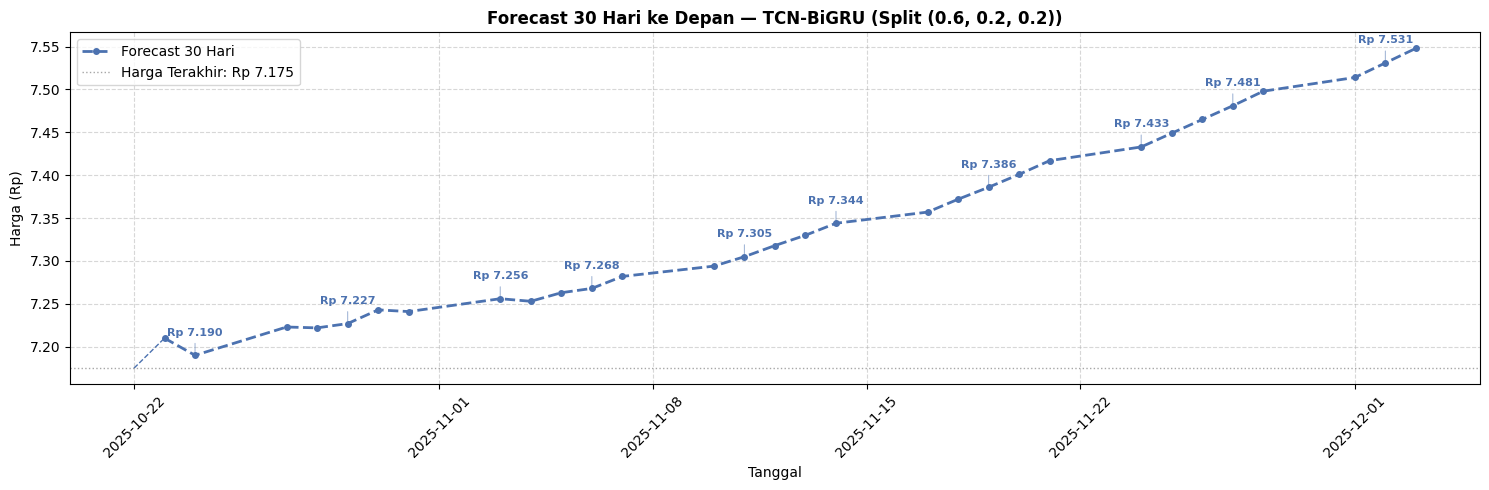

TCN-BiGRU
  Forecast Hari ke-1  : Rp 7.210
  Forecast Hari ke-30 : Rp 7.548



In [101]:
forecast_data = [
    ("TCN",   forecast_30_tcn,        colors[1], best_splits["TCN"]),
    ("BiGRU", forecast_30_bigru,      colors[2], best_splits["BiGRU"]),
    ("TCN-BiGRU",  forecast_30_tcn_bigru, colors[0], best_splits["TCN-BiGRU"]),
]

for model_name, forecast_prices, color, best_split in forecast_data:
    fig, ax = plt.subplots(figsize=(15, 5))

    # Garis penghubung dari harga terakhir ke forecast hari ke-1
    ax.plot([last_actual_date, forecast_dates[0]],
            [last_actual_price, forecast_prices[0]],
            color=color, linestyle='--', linewidth=1)

    # Line forecast 30 hari
    ax.plot(forecast_dates, forecast_prices,
            label='Forecast 30 Hari', color=color,
            linestyle='--', linewidth=2, marker='o', markersize=4)

    # ← TAMBAHAN: anotasi harga tiap 5 hari
    for j in [1, 4, 7, 10, 13, 16, 19, 22, 25, 28]:  # index hari ke-5,10,15,20,25,30
        price = forecast_prices[j]
        date  = forecast_dates[j]
        ax.annotate(
            f"Rp {price:,.3f}",
            xy=(date, price),
            xytext=(0, 14),          # 14px ke atas dari titik
            textcoords="offset points",
            ha='center',
            fontsize=8,
            color=color,
            fontweight='bold',
            arrowprops=dict(arrowstyle='-', color=color, lw=0.8, alpha=0.5)
        )

    # Garis referensi harga terakhir
    ax.axhline(y=last_actual_price, color='gray', linestyle=':', linewidth=1,
               alpha=0.7, label=f'Harga Terakhir: Rp {last_actual_price:,.3f}')

    ax.set_title(f"Forecast 30 Hari ke Depan — {model_name} (Split {best_split})",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Tanggal")
    ax.set_ylabel("Harga (Rp)")
    ax.legend()
    ax.grid(linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print(f"{model_name}")
    print(f"  Forecast Hari ke-1  : Rp {forecast_prices[0]:,.3f}")
    print(f"  Forecast Hari ke-30 : Rp {forecast_prices[-1]:,.3f}\n")

TABEL FORECAST 30 HARI LENGKAP

In [102]:
forecast_dates = pd.to_datetime(tcn_bigru["forecast_30_dates"])

df_forecast_all = pd.DataFrame({
    "Hari Ke-":    range(1, 31),
    "Tanggal":     [d.strftime('%Y-%m-%d') for d in forecast_dates],
    "TCN-BiGRU":  [round(v, 3) for v in tcn_bigru["forecast_30_prices"]],
    "TCN":   [round(v, 3) for v in tcn["forecast_30_prices"]],
    "BiGRU": [round(v, 3) for v in bigru["forecast_30_prices"]],
})

print("=" * 60)
print("TABEL FORECAST 30 HARI — SEMUA MODEL")
print("=" * 60)
display(df_forecast_all)

TABEL FORECAST 30 HARI — SEMUA MODEL


,Hari Ke-,Tanggal,TCN-BiGRU,TCN,BiGRU
0,1,2025-10-23,7.210,7.170,7.184
1,2,2025-10-24,7.190,7.186,7.170
2,3,2025-10-27,7.223,7.181,7.158
3,4,2025-10-28,7.222,7.178,7.145
4,5,2025-10-29,7.227,7.195,7.138
5,6,2025-10-30,7.243,7.191,7.140
6,7,2025-10-31,7.241,7.198,7.147
7,8,2025-11-03,7.256,7.204,7.150
8,9,2025-11-04,7.253,7.195,7.150
9,10,2025-11-05,7.263,7.192,7.146


CHART FORECAST 30 HARI (3 model dalam 1 plot)

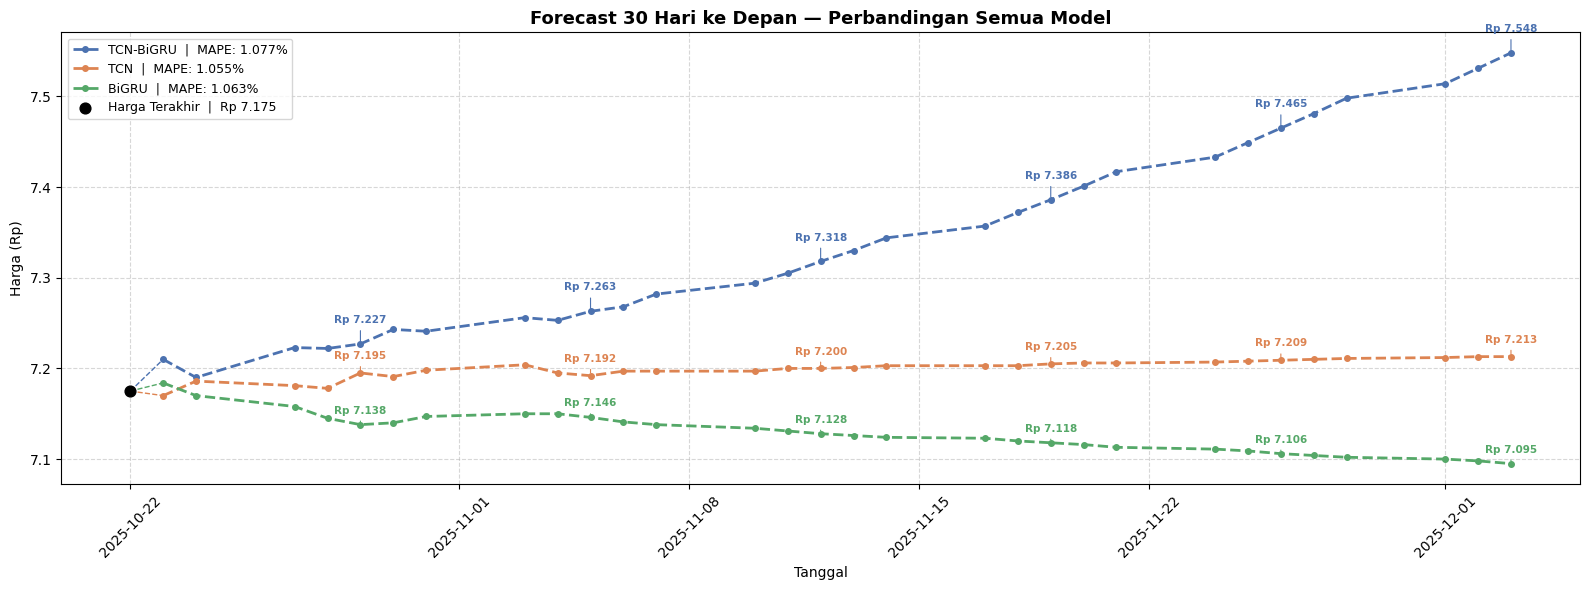

In [103]:
last_actual_price = tcn_bigru["last_actual_price"]
last_actual_date  = pd.to_datetime(tcn_bigru["last_actual_date"])

fig, ax = plt.subplots(figsize=(16, 6))

for i, (model_name, pkl, color) in enumerate([
    ("TCN-BiGRU",  tcn_bigru, colors[0]),
    ("TCN",   tcn,       colors[1]),
    ("BiGRU", bigru,     colors[2]),
]):
    prices = pkl["forecast_30_prices"]
    dates  = pd.to_datetime(pkl["forecast_30_dates"])
    mape   = pkl["mape"]

    # Garis dari harga terakhir ke hari ke-1
    ax.plot([last_actual_date, dates[0]],
            [last_actual_price, prices[0]],
            color=color, linestyle='--', linewidth=1)

    # Line forecast — label sekarang include MAPE
    ax.plot(dates, prices,
            label=f"{model_name}  |  MAPE: {mape:.3f}%",
            color=color, linestyle='--', linewidth=2,
            marker='o', markersize=4)

    # Anotasi harga tiap 5 hari (hari ke-5, 10, 15, 20, 25, 30)
    for j, (date, price) in enumerate(zip(dates, prices)):
        if (j + 1) % 5 == 0:  # hari ke-5, 10, 15, 20, 25, 30
            # offset vertikal beda tiap model biar tidak tumpuk
            offset = [15, 10, 8][i]
            ax.annotate(
                f"Rp {price:,.3f}",
                xy=(date, price),
                xytext=(0, offset),
                textcoords="offset points",
                ha='center',
                fontsize=7.5,
                color=color,
                fontweight='bold',
                arrowprops=dict(arrowstyle='-', color=color, lw=0.8)
            )

# Titik aktual terakhir
ax.scatter(last_actual_date, last_actual_price,
           color='black', zorder=5, s=60,
           label=f'Harga Terakhir  |  Rp {last_actual_price:,.3f}')

ax.set_title("Forecast 30 Hari ke Depan — Perbandingan Semua Model",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Tanggal")
ax.set_ylabel("Harga (Rp)")
ax.legend(loc='best', fontsize=9)
ax.grid(linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KESIMPULAN

In [111]:
models_list = ["TCN-BiGRU", "TCN", "BiGRU"]
pkls        = [tcn_bigru, tcn, bigru]

mapes   = [p["mape"]  for p in pkls]
maes    = [p["mae"]   for p in pkls]
rmses   = [p["rmse"]  for p in pkls]
r2s     = [p["r2"]    for p in pkls]
times   = [p["total_time"] for p in pkls]
h1s     = [p["forecast_h1"] for p in pkls]

best_mape  = models_list[mapes.index(min(mapes))]
best_mae   = models_list[maes.index(min(maes))]
best_rmse  = models_list[rmses.index(min(rmses))]
best_r2    = models_list[r2s.index(max(r2s))]
best_time  = models_list[times.index(min(times))]
highest_h1 = models_list[h1s.index(max(h1s))]
lowest_h1  = models_list[h1s.index(min(h1s))]

mape_hybrid  = tcn_bigru["mape"]
mape_tcn     = tcn["mape"]
time_hybrid  = tcn_bigru["total_time"]
time_tcn     = tcn["total_time"]
mape_gap     = abs(mape_hybrid - mape_tcn)
time_gap     = abs(time_hybrid - time_tcn)

# Model terbaik overall: MAPE terkecil + R² terbesar (skor gabungan)
# Normalisasi: MAPE makin kecil makin baik, R² makin besar makin baik
import numpy as np
mape_norm = [(m - min(mapes)) / (max(mapes) - min(mapes)) if max(mapes) != min(mapes) else 0 for m in mapes]
r2_norm   = [(max(r2s) - r) / (max(r2s) - min(r2s)) if max(r2s) != min(r2s) else 0 for r in r2s]
scores    = [m + r for m, r in zip(mape_norm, r2_norm)]  # makin kecil makin baik
best_overall = models_list[scores.index(min(scores))]

print("=" * 60)
print("📋 KESIMPULAN PERBANDINGAN MODEL")
print("=" * 60)
print(f"1. 🏆 MAPE terbaik (terendah)    : {best_mape.ljust(12)} ({min(mapes):.4f}%)")
print(f"2. 📉 RMSE terkecil              : {best_rmse.ljust(12)} ({min(rmses):.4f})")
print(f"3. 📏 MAE terkecil               : {best_mae.ljust(12)} ({min(maes):.4f})")
print(f"4. 📈 R² terbesar                : {best_r2.ljust(12)} ({max(r2s):.4f})")
print(f"5. ⚡ Training time tercepat      : {best_time.ljust(12)} ({min(times):.2f} detik)")
print(f"6. 📊 Forecast H+1 tertinggi     : {highest_h1.ljust(12)} (Rp {max(h1s):.3f})")
print(f"7. 📊 Forecast H+1 terendah      : {lowest_h1.ljust(12)} (Rp {min(h1s):.3f})")
print(f"8. 🥇 Model terbaik keseluruhan  : {best_overall.ljust(12)}")
if best_mape == best_rmse == best_r2:
    print(f"9. ✅ Model {best_mape} konsisten terbaik di MAPE, RMSE, dan R²")
else:
    print(f"9. ⚠️  Tidak ada model yang dominan di semua metrik sekaligus")
if best_mape == best_time:
    print(f"10. ✅ {best_mape} unggul di akurasi sekaligus training tercepat")
else:
    print(f"10. ⚖️  Trade-off: akurasi terbaik={best_mape}, tercepat={best_time}")
mape_gap = max(mapes) - min(mapes)
print(f"11. 📐 Selisih MAPE terbesar-terkecil : {mape_gap:.4f}%")
if mape_gap < 0.5:
    print(f"     → Perbedaan antar model sangat kecil (<0.5%), performa relatif setara")
elif mape_gap < 2:
    print(f"     → Perbedaan antar model moderat")
else:
    print(f"     → Perbedaan antar model cukup signifikan")
print("=" * 60)
for name, h1 in zip(models_list, h1s):
    arah = "naik ↑" if h1 > last_actual_price else "turun ↓"
    selisih = abs(h1 - last_actual_price)
    print(f"{name.ljust(12)} forecast H+1 {arah} (selisih Rp {selisih:.3f})")
print("=" * 60)
if best_mape != best_rmse:
    print(f"13. 💡 TCN unggul MAPE & MAE, tapi BiGRU unggul RMSE & R²")
    print(f"     → TCN lebih baik di error rata-rata harian")
    print(f"     → BiGRU lebih baik menangani lonjakan error ekstrem")
print("=" * 60)
print(f"14. 🤔 Apakah TCN-BiGRU masih relevan?")
print(f"     MAPE TCN-BiGRU : {mape_hybrid:.4f}%")
print(f"     MAPE TCN       : {mape_tcn:.4f}%")
print(f"     Selisih MAPE   : {mape_gap:.4f}%")
print(f"     Selisih waktu  : {time_gap:.2f} detik atau {time_gap/60:.2f} menit lebih lama")

if mape_gap < 0.5 and time_hybrid > time_tcn:
    print(f"TCN-BiGRU TIDAK signifikan lebih baik dari TCN,")
    print(f"sementara membutuhkan {time_gap:.2f} detik atau {time_gap/60:.2f} menit lebih lama.")
    print(f"Untuk kasus ini, TCN lebih direkomendasikan")
    print(f"karena lebih efisien tanpa kehilangan akurasi berarti.")
elif mape_hybrid < mape_tcn and mape_gap >= 0.5:
    print(f"TCN-BiGRU terbukti lebih akurat secara signifikan (>{0.5}%),")
    print(f"kompleksitas tambahan BiGRU memberikan manfaat nyata.")
elif mape_hybrid > mape_tcn:
    print(f"TCN bahkan lebih akurat dari TCN-BiGRU.")
    print(f"Penambahan BiGRU tidak memberikan manfaat pada dataset ini.")
print("=" * 60)

📋 KESIMPULAN PERBANDINGAN MODEL
1. 🏆 MAPE terbaik (terendah)    : TCN          (1.0553%)
2. 📉 RMSE terkecil              : BiGRU        (0.1073)
3. 📏 MAE terkecil               : TCN          (0.0758)
4. 📈 R² terbesar                : BiGRU        (0.9784)
5. ⚡ Training time tercepat      : TCN          (542.85 detik)
6. 📊 Forecast H+1 tertinggi     : TCN-BiGRU    (Rp 7.210)
7. 📊 Forecast H+1 terendah      : TCN          (Rp 7.170)
8. 🥇 Model terbaik keseluruhan  : TCN         
9. ⚠️  Tidak ada model yang dominan di semua metrik sekaligus
10. ✅ TCN unggul di akurasi sekaligus training tercepat
11. 📐 Selisih MAPE terbesar-terkecil : 0.0213%
     → Perbedaan antar model sangat kecil (<0.5%), performa relatif setara
TCN-BiGRU    forecast H+1 naik ↑ (selisih Rp 0.035)
TCN          forecast H+1 turun ↓ (selisih Rp 0.005)
BiGRU        forecast H+1 naik ↑ (selisih Rp 0.009)
13. 💡 TCN unggul MAPE & MAE, tapi BiGRU unggul RMSE & R²
     → TCN lebih baik di error rata-rata harian
     → BiGRU le